# 04 · Comparación entre prompts

## Alcance de esta contribución

Este notebook consolida las diferencias entre los cuatro prompts que ya se insinuaron en notebooks anteriores. El notebook 01 reportó la cobertura por prompt y el notebook 03 comparó medianas de longitud; aquí se repiten de forma compacta solo como referencia y se responde lo que faltaba: si `content` y `wording` difieren de nivel entre prompts (no solo su correlación mutua, ya calculada en el notebook 02) y si hay señales de que unos prompts son más exigentes que otros.

La pregunta es si el prompt que le tocó a un estudiante se asocia con su puntuación, su extensión y cuánto se apoya en el texto fuente. Ninguna asociación se interpreta como una medida objetiva de dificultad: los cuatro prompts tratan temas distintos y pueden tener criterios de evaluación implícitamente distintos.

## 1. Preparación reproducible

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents]
     if (path / "src").is_dir() and (path / "notebooks").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontró la raíz del proyecto.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_csv_files
from src.tokenization import tokenize_text
from src.ngrams import prompt_ngram_overlap

INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
for directory in [TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

clean_files = ["summaries_train_clean.csv", "prompts_train_clean.csv"]
if not all((INTERIM_DATA_DIR / name).is_file() for name in clean_files):
    raise FileNotFoundError(
        "Faltan las copias limpias. Ejecute primero 00_data_loading.ipynb "
        "y 01_data_quality.ipynb con los CSV de entrenamiento en data/raw/."
    )
datasets = load_csv_files(INTERIM_DATA_DIR, clean_files)
summaries = datasets["summaries_train_clean"]
prompts = datasets["prompts_train_clean"]
assert not summaries.empty, "No hay resúmenes para analizar."
assert summaries["student_id"].notna().all() and summaries["student_id"].is_unique
assert prompts["prompt_id"].notna().all() and prompts["prompt_id"].is_unique
assert summaries["prompt_id"].notna().all()
assert summaries["prompt_id"].isin(prompts["prompt_id"]).all()

plt.rcParams.update({"figure.figsize": [10, 4], "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

Antes de comparar los prompts se añaden dos columnas derivadas, reutilizando funciones ya construidas en el proyecto: `token_count` (tokenización de `src.tokenization`) y `word_overlap`, la proporción de palabras únicas del resumen que también aparece en su prompt (`prompt_ngram_overlap` de `src.ngrams`, con n=1).

In [2]:
prompt_tokens = prompts.set_index("prompt_id")["prompt_text"].map(tokenize_text)

summaries = summaries.assign(tokens=summaries["text"].map(tokenize_text))
summaries["token_count"] = summaries["tokens"].map(len)
summaries["word_overlap"] = summaries.apply(
    lambda row: prompt_ngram_overlap(row["tokens"], prompt_tokens[row["prompt_id"]], n=1),
    axis=1,
)
summaries = summaries.merge(prompts[["prompt_id", "prompt_title"]], on="prompt_id", how="left")
assert summaries["token_count"].gt(0).all(), "Hay resúmenes sin tokens."
assert summaries["prompt_title"].notna().all(), "Quedaron resúmenes sin título de prompt."
summaries[["student_id", "prompt_title", "token_count", "word_overlap"]].head(3)

,student_id,prompt_title,token_count,word_overlap
0,000e8c3c7ddb,The Third Wave,61,0.489796
1,0020ae56ffbf,Excerpt from The Jungle,52,0.942857
2,004e978e639e,Egyptian Social Structure,237,0.583942


## 2. Cobertura y balance por prompt

El detalle completo de esta comparación ya está en el notebook 01; se repite aquí de forma compacta para responder la primera pregunta en el mismo lugar que las demás.

,prompt_id,prompt_title,resúmenes,proporción
0,39c16e,On Tragedy,2057,0.287090
1,3b9047,Egyptian Social Structure,2009,0.280391
2,ebad26,Excerpt from The Jungle,1996,0.278576
3,814d6b,The Third Wave,1103,0.153943


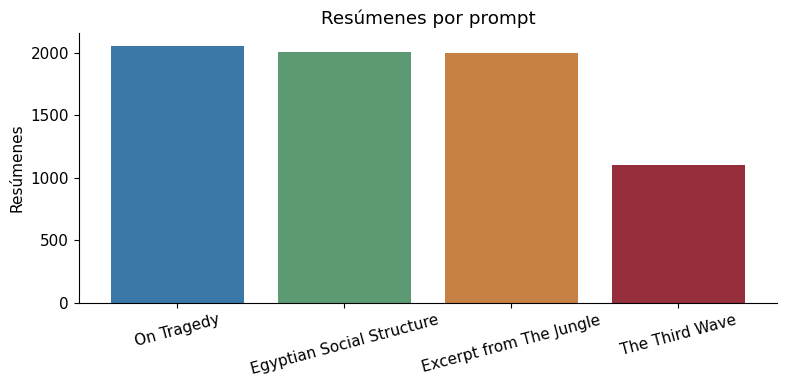

In [3]:
coverage = (
    summaries.groupby(["prompt_id", "prompt_title"], sort=False)
    .size()
    .rename("resúmenes")
    .reset_index()
)
coverage["proporción"] = coverage["resúmenes"] / coverage["resúmenes"].sum()
coverage = coverage.sort_values("resúmenes", ascending=False).reset_index(drop=True)
display(coverage)
prompt_order = coverage["prompt_title"].tolist()

fig, ax = plt.subplots(figsize=[8, 4])
colors = ["#3978a8", "#5b9a72", "#c78145", "#972e3b"]
ax.bar(coverage["prompt_title"], coverage["resúmenes"], color=colors)
ax.set(title="Resúmenes por prompt", xlabel="", ylabel="Resúmenes")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_prompt_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

coverage.to_csv(TABLES_DIR / "04_prompt_coverage.csv", index=False)

## 3. Puntuaciones por prompt

¿Hay prompts con mejores scores? Se compara la distribución completa de `content` y `wording`, no solo su media. La comparación no equivale a un juicio de calidad de los prompts: puede reflejar también dificultad temática o criterios de evaluación distintos entre textos.

content                                          \
                            count    mean     std     min      1%     25%   
prompt_title                                                                
On Tragedy                 2057.0 -0.0955  0.9698 -1.7299 -1.5472 -0.8106   
Egyptian Social Structure  2009.0  0.0496  1.1061 -1.7299 -1.5472 -0.7995   
Excerpt from The Jungle    1996.0 -0.0879  0.9903 -1.6385 -1.5472 -0.8620   
The Third Wave             1103.0  0.1503  1.1242 -1.7299 -1.5472 -0.6276   

                                                          wording          \
                              50%     75%     99%     max   count    mean   
prompt_title                                                                
On Tragedy                -0.1575  0.2970  3.0408  3.9003  2057.0 -0.1407   
Egyptian Social Structure -0.0938  0.7021  2.9547  3.8941  2009.0 -0.0685   
Excerpt from The Jungle   -0.0938  0.4400  2.5740  3.5032  1996.0 -0.2990   
The Third Wave            -0.0938  0.7936  3.1435  3.7114  1103.0  0.5187   

                                                                           \
                              std     min      1%     25%     50%     75%   
prompt_title                                                                
On Tragedy                 1.0557 -1.9626 -1.6722 -0.9702 -0.1687  0.5009   
Egyptian Social Structure  0.9527 -1.7955 -1.7955 -0.7946 -0.0454  0.5068   
Excerpt from The Jungle    0.9303 -1.7955 -1.7955 -1.0504 -0.2844  0.3805   
The Third Wave             1.1078 -1.7955 -1.5488 -0.1256  0.5038  1.1333   

                                           
                              99%     max  
prompt_title                               
On Tragedy                 3.0705  4.1874  
Egyptian Social Structure  2.3444  4.2312  
Excerpt from The Jungle    2.2189  3.6381  
The Third Wave             3.3927  4.3107

content    0.0080
wording    0.0646
Name: eta_cuadrado, dtype: float64

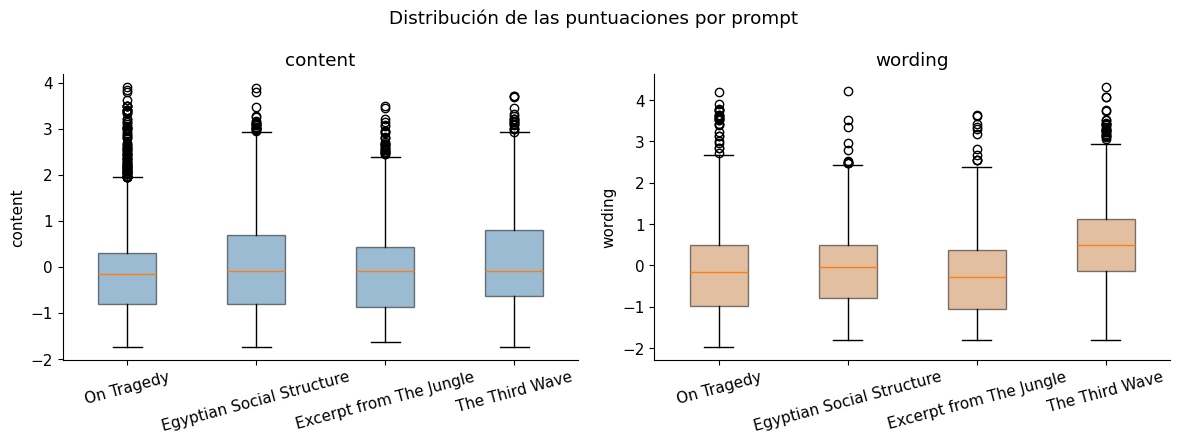

In [4]:
target_columns = ["content", "wording"]

target_by_prompt = (
    summaries.groupby("prompt_title")[target_columns]
    .describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
    .loc[prompt_order]
)
display(target_by_prompt.round(4))

def eta_squared(frame, target, group_column="prompt_title"):
    """Proporción de la varianza de `target` explicada por `group_column`."""
    grand_mean = frame[target].mean()
    ss_total = ((frame[target] - grand_mean) ** 2).sum()
    group_stats = frame.groupby(group_column)[target].agg(["mean", "size"])
    ss_between = (group_stats["size"] * (group_stats["mean"] - grand_mean) ** 2).sum()
    return ss_between / ss_total

effect_sizes = pd.Series(
    {target: eta_squared(summaries, target) for target in target_columns},
    name="eta_cuadrado",
)
display(effect_sizes.round(4))

fig, axes = plt.subplots(1, 2, figsize=[12, 4.5])
for ax, target, color in zip(axes, target_columns, ["#3978a8", "#c78145"]):
    data = [summaries.loc[summaries["prompt_title"] == title, target] for title in prompt_order]
    ax.boxplot(data, tick_labels=prompt_order, patch_artist=True,
               boxprops={"facecolor": color, "alpha": 0.5})
    ax.set(title=target, ylabel=target)
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Distribución de las puntuaciones por prompt")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_prompt_target_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

target_export = target_by_prompt.copy()
target_export.columns = ["_".join(col) for col in target_export.columns]
target_export.reset_index().to_csv(TABLES_DIR / "04_prompt_target_descriptive.csv", index=False)

## 4. Longitud de las respuestas por prompt

El notebook 03 ya comparó las medianas de `token_count` por prompt; aquí se muestra la distribución completa para ver si además cambia la dispersión.

,count,mean,std,min,1%,25%,50%,75%,99%,max
prompt_title,,,,,,,,,,
On Tragedy,2057.0,63.0,44.6,25.0,26.0,36.0,50.0,73.0,226.4,637.0
Egyptian Social Structure,2009.0,84.1,60.9,25.0,26.0,43.0,65.0,106.0,288.9,660.0
Excerpt from The Jungle,1996.0,79.9,56.0,25.0,26.0,41.0,63.0,101.0,290.8,513.0
The Third Wave,1103.0,73.0,46.8,26.0,26.0,40.0,59.0,90.0,236.0,393.0


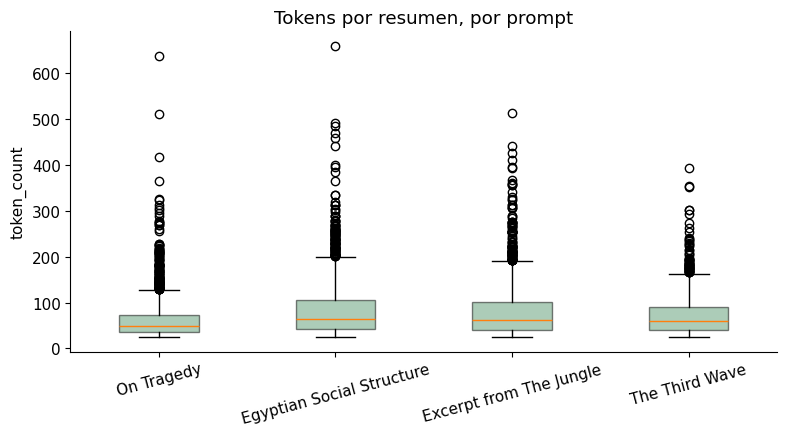

In [5]:
length_by_prompt = (
    summaries.groupby("prompt_title")["token_count"]
    .describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
    .loc[prompt_order]
)
display(length_by_prompt.round(1))

fig, ax = plt.subplots(figsize=[8, 4.5])
data = [summaries.loc[summaries["prompt_title"] == title, "token_count"] for title in prompt_order]
ax.boxplot(data, tick_labels=prompt_order, patch_artist=True,
           boxprops={"facecolor": "#5b9a72", "alpha": 0.5})
ax.set(title="Tokens por resumen, por prompt", ylabel="token_count")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_prompt_length_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

length_by_prompt.reset_index().to_csv(TABLES_DIR / "04_prompt_length_descriptive.csv", index=False)

## 5. ¿La dificultad parece diferente?

No hay una columna de dificultad en los datos originales: se construye un perfil descriptivo por prompt combinando la longitud del texto fuente, la longitud típica de la respuesta, las puntuaciones obtenidas y cuánto se apoya cada resumen en el prompt. Con solo cuatro prompts no hay base para una prueba estadística formal. Se describe el patrón, no se prueba una causa.

,prompt_id,prompt_title,resúmenes,mediana_tokens_respuesta,mediana_content,mediana_wording,mediana_word_overlap,prompt_token_count
0,39c16e,On Tragedy,2057,50.0,-0.157,-0.169,0.696,600
1,814d6b,The Third Wave,1103,59.0,-0.094,0.504,0.615,598
2,ebad26,Excerpt from The Jungle,1996,63.0,-0.094,-0.284,0.780,976
3,3b9047,Egyptian Social Structure,2009,65.0,-0.094,-0.045,0.688,554


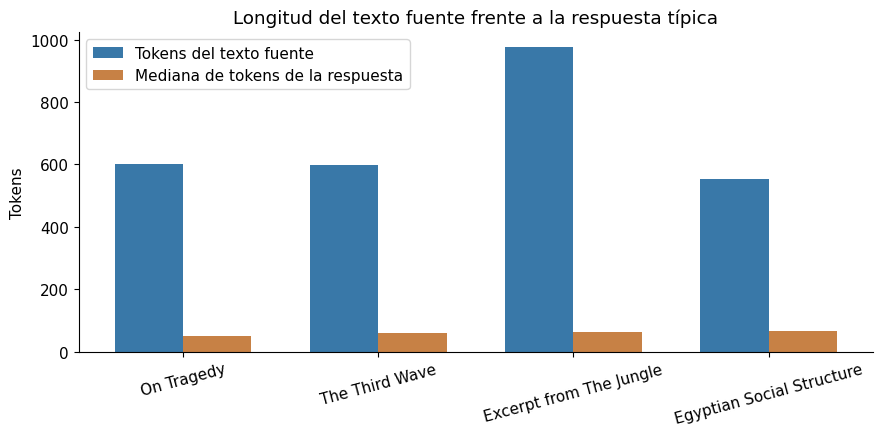

In [6]:
prompt_source_length = prompt_tokens.map(len).rename("prompt_token_count")

difficulty_profile = (
    summaries.groupby(["prompt_id", "prompt_title"], sort=False)
    .agg(
        resúmenes=("student_id", "size"),
        mediana_tokens_respuesta=("token_count", "median"),
        mediana_content=("content", "median"),
        mediana_wording=("wording", "median"),
        mediana_word_overlap=("word_overlap", "median"),
    )
    .reset_index()
    .merge(prompt_source_length, left_on="prompt_id", right_index=True)
    .sort_values("mediana_content")
    .reset_index(drop=True)
)
display(difficulty_profile.round(3))

fig, ax = plt.subplots(figsize=[9, 4.5])
x = np.arange(len(difficulty_profile))
width = 0.35
ax.bar(x - width / 2, difficulty_profile["prompt_token_count"], width,
       label="Tokens del texto fuente", color="#3978a8")
ax.bar(x + width / 2, difficulty_profile["mediana_tokens_respuesta"], width,
       label="Mediana de tokens de la respuesta", color="#c78145")
ax.set_xticks(x)
ax.set_xticklabels(difficulty_profile["prompt_title"], rotation=15)
ax.set(title="Longitud del texto fuente frente a la respuesta típica", ylabel="Tokens")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_prompt_difficulty_profile.png", dpi=150, bbox_inches="tight")
plt.show()

difficulty_profile.to_csv(TABLES_DIR / "04_prompt_difficulty_profile.csv", index=False)

## 6. Resultado, interpretación y limitaciones

El siguiente resumen se calcula con los datos cargados.

In [7]:
max_coverage = coverage.loc[coverage["resúmenes"].idxmax()]
min_coverage = coverage.loc[coverage["resúmenes"].idxmin()]
print(
    f"Los cuatro prompts no tienen el mismo número de respuestas: de "
    f"{min_coverage['resúmenes']} en '{min_coverage['prompt_title']}' a "
    f"{max_coverage['resúmenes']} en '{max_coverage['prompt_title']}'."
)

best_content = difficulty_profile.loc[difficulty_profile["mediana_content"].idxmax()]
worst_content = difficulty_profile.loc[difficulty_profile["mediana_content"].idxmin()]
best_wording = difficulty_profile.loc[difficulty_profile["mediana_wording"].idxmax()]
worst_wording = difficulty_profile.loc[difficulty_profile["mediana_wording"].idxmin()]
print(
    f"La mediana de content más alta es {best_content['mediana_content']:.3f} en "
    f"'{best_content['prompt_title']}' y la más baja es {worst_content['mediana_content']:.3f} en "
    f"'{worst_content['prompt_title']}'."
)
print(
    f"La mediana de wording más alta es {best_wording['mediana_wording']:.3f} en "
    f"'{best_wording['prompt_title']}' y la más baja es {worst_wording['mediana_wording']:.3f} en "
    f"'{worst_wording['prompt_title']}'."
)
print(
    f"El tamaño de efecto (eta cuadrado) del prompt sobre la puntuación es "
    f"{effect_sizes['content']:.3f} para content y {effect_sizes['wording']:.3f} para wording."
)

longest_prompt = difficulty_profile.loc[difficulty_profile["prompt_token_count"].idxmax()]
shortest_prompt = difficulty_profile.loc[difficulty_profile["prompt_token_count"].idxmin()]
print(
    f"El texto fuente más largo es '{longest_prompt['prompt_title']}' "
    f"({longest_prompt['prompt_token_count']:.0f} tokens) y el más corto es "
    f"'{shortest_prompt['prompt_title']}' ({shortest_prompt['prompt_token_count']:.0f} tokens)."
)
print(
    f"La mediana de tokens de respuesta va de "
    f"{difficulty_profile['mediana_tokens_respuesta'].min():.0f} a "
    f"{difficulty_profile['mediana_tokens_respuesta'].max():.0f} según el prompt."
)
print(
    f"La mediana de coincidencia léxica con el prompt va de "
    f"{difficulty_profile['mediana_word_overlap'].min():.3f} a "
    f"{difficulty_profile['mediana_word_overlap'].max():.3f}."
)
print("Limitación: con 4 prompts no hay base para un test de significancia formal; las diferencias se describen, no se prueban.")
print("Limitación: la dificultad no se observa directamente y se confunde con el tema y con la calibración del evaluador.")

Los cuatro prompts no tienen el mismo número de respuestas: de 1103 en 'The Third Wave' a 2057 en 'On Tragedy'.
La mediana de content más alta es -0.094 en 'The Third Wave' y la más baja es -0.157 en 'On Tragedy'.
La mediana de wording más alta es 0.504 en 'The Third Wave' y la más baja es -0.284 en 'Excerpt from The Jungle'.
El tamaño de efecto (eta cuadrado) del prompt sobre la puntuación es 0.008 para content y 0.065 para wording.
El texto fuente más largo es 'Excerpt from The Jungle' (976 tokens) y el más corto es 'Egyptian Social Structure' (554 tokens).
La mediana de tokens de respuesta va de 50 a 65 según el prompt.
La mediana de coincidencia léxica con el prompt va de 0.615 a 0.780.
Limitación: con 4 prompts no hay base para un test de significancia formal; las diferencias se describen, no se prueban.
Limitación: la dificultad no se observa directamente y se confunde con el tema y con la calibración del evaluador.


### Hallazgos verificados

Los cuatro prompts no reciben la misma cantidad de respuestas: van de 1,103 en "The Third Wave" (15.4 %) a 2,057 en "On Tragedy" (28.7 %), confirmando el desbalance ya visto en el notebook 01.

Sí hay diferencias de nivel entre prompts, más marcadas en `wording` que en `content`. La mediana de `content` va de -0.157 en "On Tragedy" a -0.094 en los otros tres prompts (Egyptian Social Structure, Excerpt from The Jungle y The Third Wave comparten esa misma mediana, un valor que también coincide con la mediana global del notebook 02). `wording` tiene un rango más amplio, de -0.284 en "Excerpt from The Jungle" a 0.504 en "The Third Wave". El tamaño de efecto confirma esta asimetría: el prompt explica solo el 0.8 % de la varianza de `content` (eta cuadrado = 0.008) pero el 6.5 % de la varianza de `wording` (eta cuadrado = 0.065). Saber a qué prompt respondió un estudiante dice poco sobre su contenido, pero algo más sobre su redacción.

La longitud típica de la respuesta también cambia por prompt: la mediana va de 50 tokens en "On Tragedy" a 65 en "Egyptian Social Structure", sin relación clara con la longitud del texto fuente. El prompt con el texto fuente más largo, "Excerpt from The Jungle" (976 tokens), no produce ni las respuestas más largas ni las más cortas. Tampoco aparece un patrón limpio de dificultad: "The Third Wave" tiene el texto fuente más corto (598 tokens) junto con la coincidencia léxica más baja con el prompt (mediana 0.615) y, aun así, las mejores medianas de `content` y `wording` de los cuatro, lo opuesto de lo que se esperaría si copiar más facilitara una mejor puntuación.

Estas asociaciones son descriptivas y pequeñas (eta cuadrado por debajo de 0.07 en ambos objetivos). No permiten afirmar qué prompt es "más difícil": la dificultad no se observa directamente, se infiere combinando señales indirectas que están confundidas entre sí: el tema, el criterio del evaluador y la extensión esperada de la respuesta.